In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as pt
import seaborn as se
from sklearn.model_selection import train_test_split 
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from xgboost import plot_importance
from sklearn.ensemble import RandomForestRegressor

In [2]:
df=pd.read_csv("working_walmart_data.csv")

In [46]:
df.to_csv('working_walmart_data.csv')

In [ ]:
#EDA

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [4]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [5]:
df.tail()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
6430,45,28-09-2012,713173.95,0,64.88,3.997,192.013558,8.684
6431,45,05-10-2012,733455.07,0,64.89,3.985,192.170412,8.667
6432,45,12-10-2012,734464.36,0,54.47,4.000,192.327265,8.667
6433,45,19-10-2012,718125.53,0,56.47,3.969,192.330854,8.667
6434,45,26-10-2012,760281.43,0,58.85,3.882,192.308899,8.667


In [11]:
df.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


In [7]:
df.nunique

<bound method DataFrame.nunique of       Store        Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0         1  05-02-2010    1643690.90             0        42.31       2.572   
1         1  12-02-2010    1641957.44             1        38.51       2.548   
2         1  19-02-2010    1611968.17             0        39.93       2.514   
3         1  26-02-2010    1409727.59             0        46.63       2.561   
4         1  05-03-2010    1554806.68             0        46.50       2.625   
...     ...         ...           ...           ...          ...         ...   
6430     45  28-09-2012     713173.95             0        64.88       3.997   
6431     45  05-10-2012     733455.07             0        64.89       3.985   
6432     45  12-10-2012     734464.36             0        54.47       4.000   
6433     45  19-10-2012     718125.53             0        56.47       3.969   
6434     45  26-10-2012     760281.43             0        58.85       3.882   

    

In [8]:
df.shape

(6435, 8)

In [12]:
df.isnull().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

In [13]:
(df.isnull().sum()/len(df))*100

Store           0.0
Date            0.0
Weekly_Sales    0.0
Holiday_Flag    0.0
Temperature     0.0
Fuel_Price      0.0
CPI             0.0
Unemployment    0.0
dtype: float64

In [9]:
df['Date']=pd.to_datetime(df['Date'],dayfirst=True)

In [25]:
df=df.drop(columns=['DAY'])

In [27]:
df['YEAR']=df['Date'].dt.year

In [29]:
df['DAY']=df['Date'].dt.weekday

In [31]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,MONTH,YEAR,DAY
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2,2010,4
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2,2010,4
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2,2010,4
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2,2010,4
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,3,2010,4


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
 8   MONTH         6435 non-null   int32         
 9   YEAR          6435 non-null   int32         
 10  DAY           6435 non-null   int32         
dtypes: datetime64[ns](1), float64(5), int32(3), int64(2)
memory usage: 477.7 KB


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    6435 non-null   int64  
 1   Store         6435 non-null   int64  
 2   Date          6435 non-null   object 
 3   Weekly_Sales  6435 non-null   float64
 4   Holiday_Flag  6435 non-null   int64  
 5   Temperature   6435 non-null   float64
 6   Fuel_Price    6435 non-null   float64
 7   CPI           6435 non-null   float64
 8   Unemployment  6435 non-null   float64
 9   MONTH         6435 non-null   int64  
 10  YEAR          6435 non-null   int64  
 11  DAY           6435 non-null   int64  
dtypes: float64(5), int64(6), object(1)
memory usage: 603.4+ KB


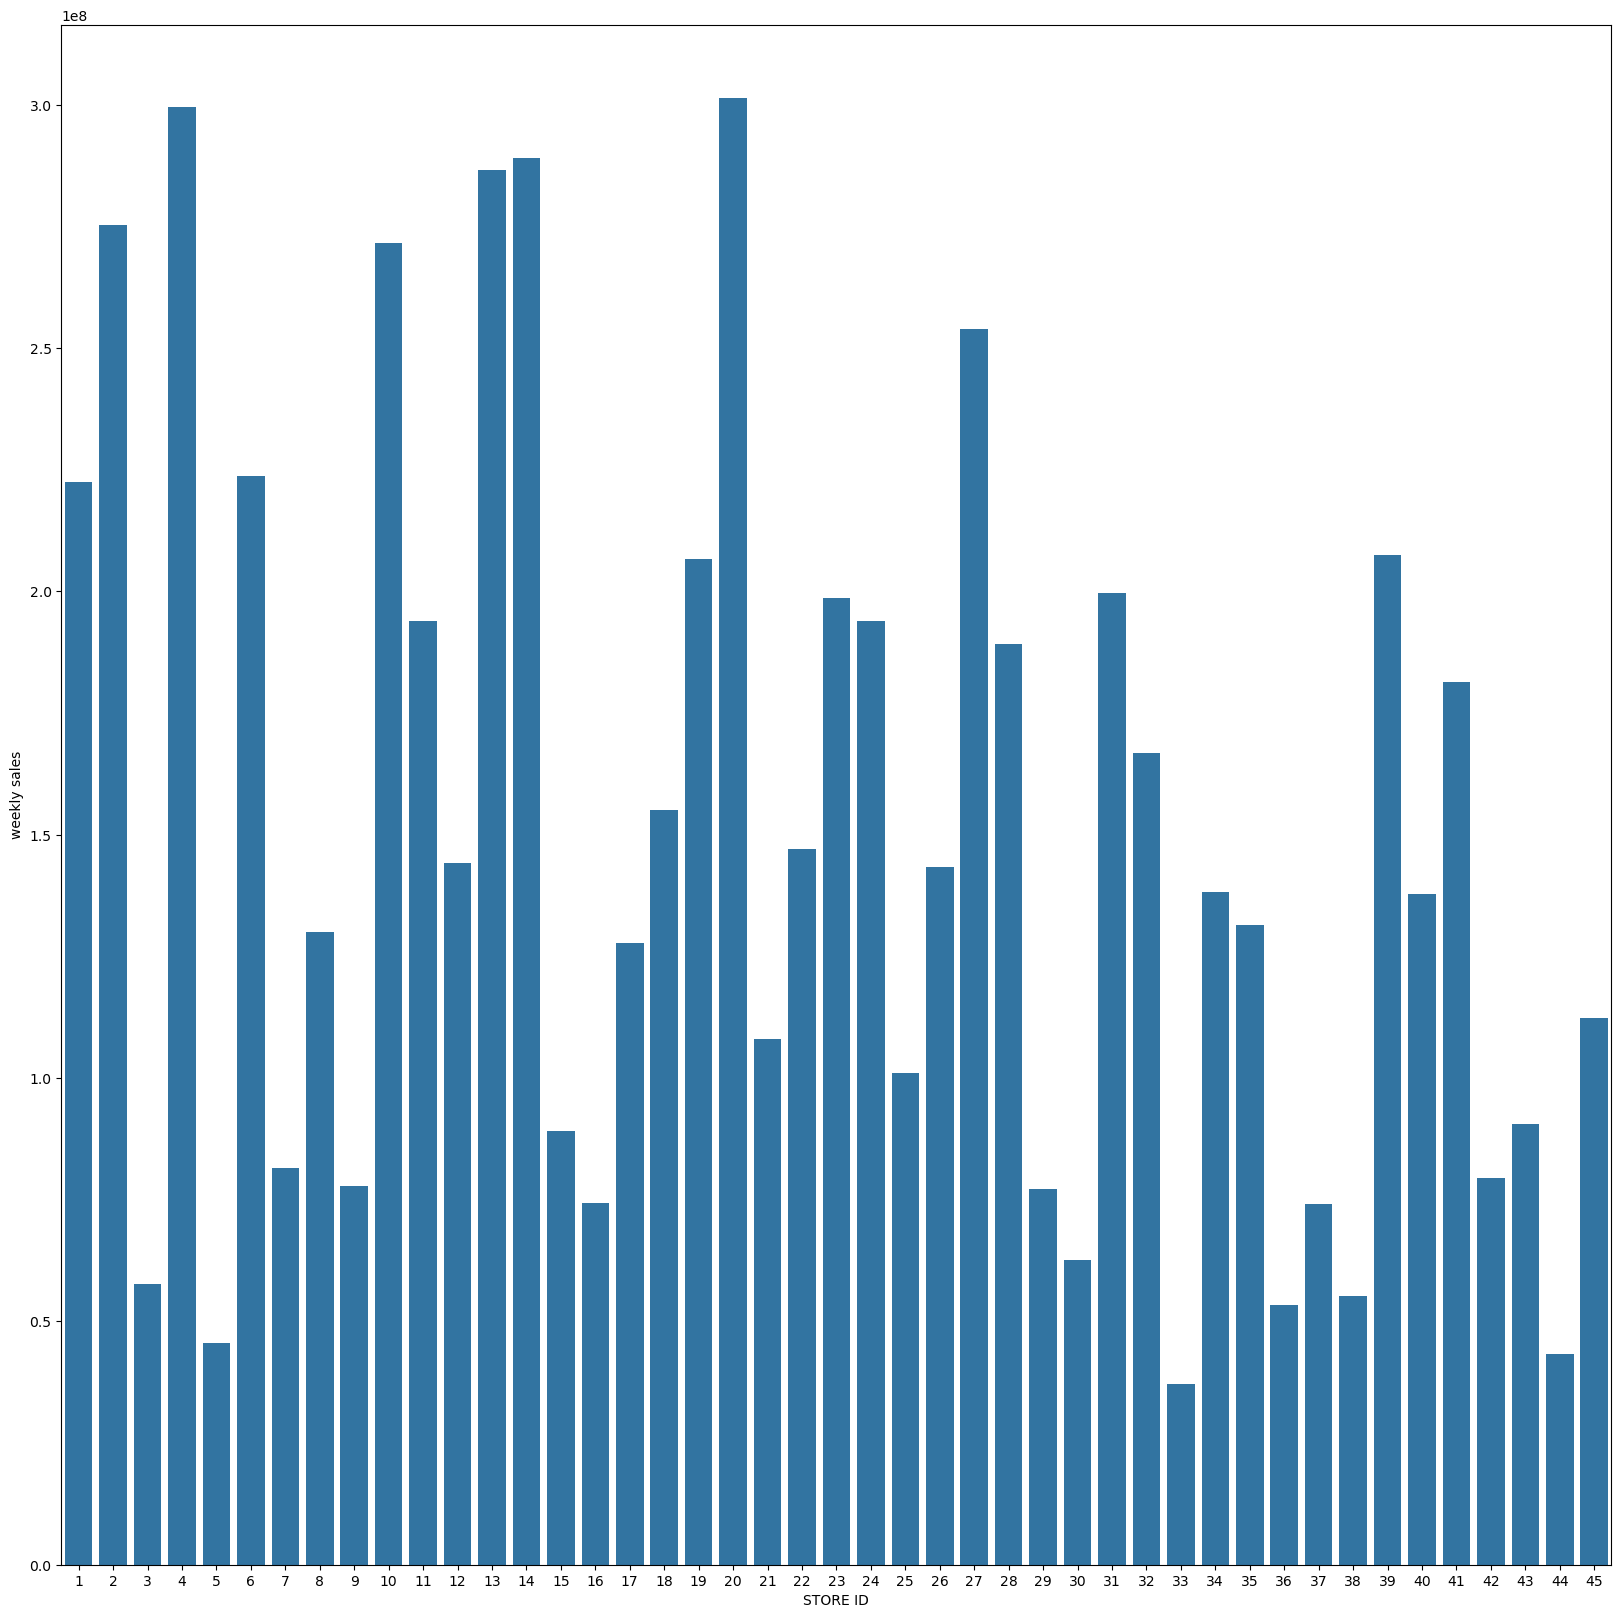

In [7]:
weekly_sales=df.groupby('Store')['Weekly_Sales'].sum()
pt.figure(figsize=(20,20))
se.barplot(x=weekly_sales.index,y=weekly_sales.values)
pt.xlabel('STORE ID')
pt.ylabel('weekly sales')
pt.show()
#conclusion is that the STORE 20 sales are high

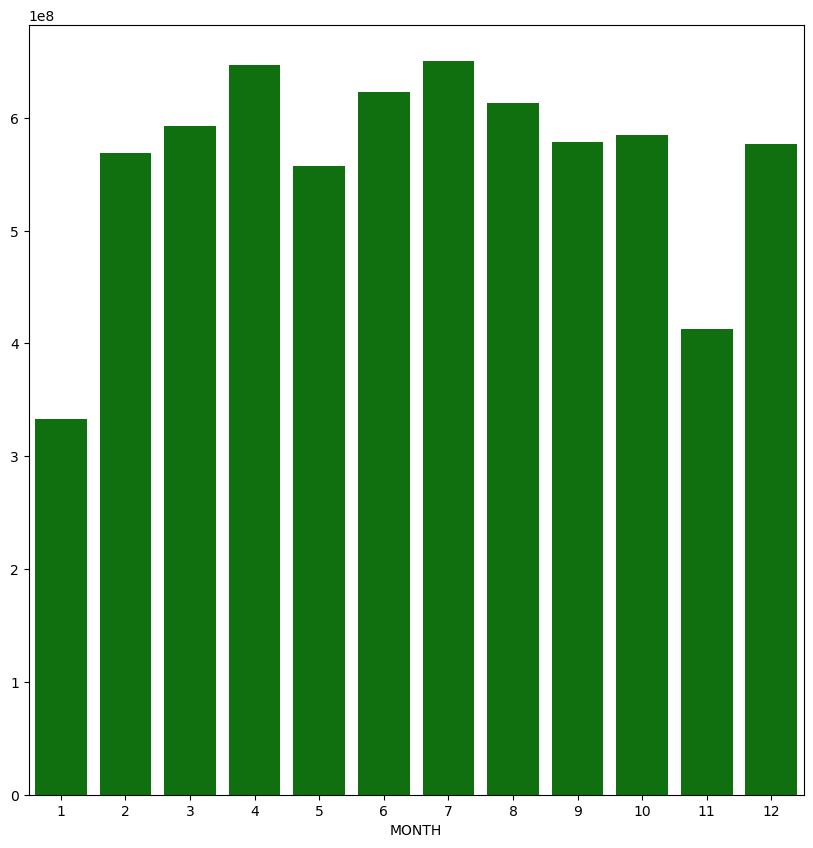

In [38]:
monthly_Sales=df.groupby('MONTH')['Weekly_Sales'].sum()
pt.figure(figsize=(10,10))
se.barplot(x=monthly_Sales.index,y=monthly_Sales.values,color='g')
pt.show()
#conclucion:the july month has peak sales

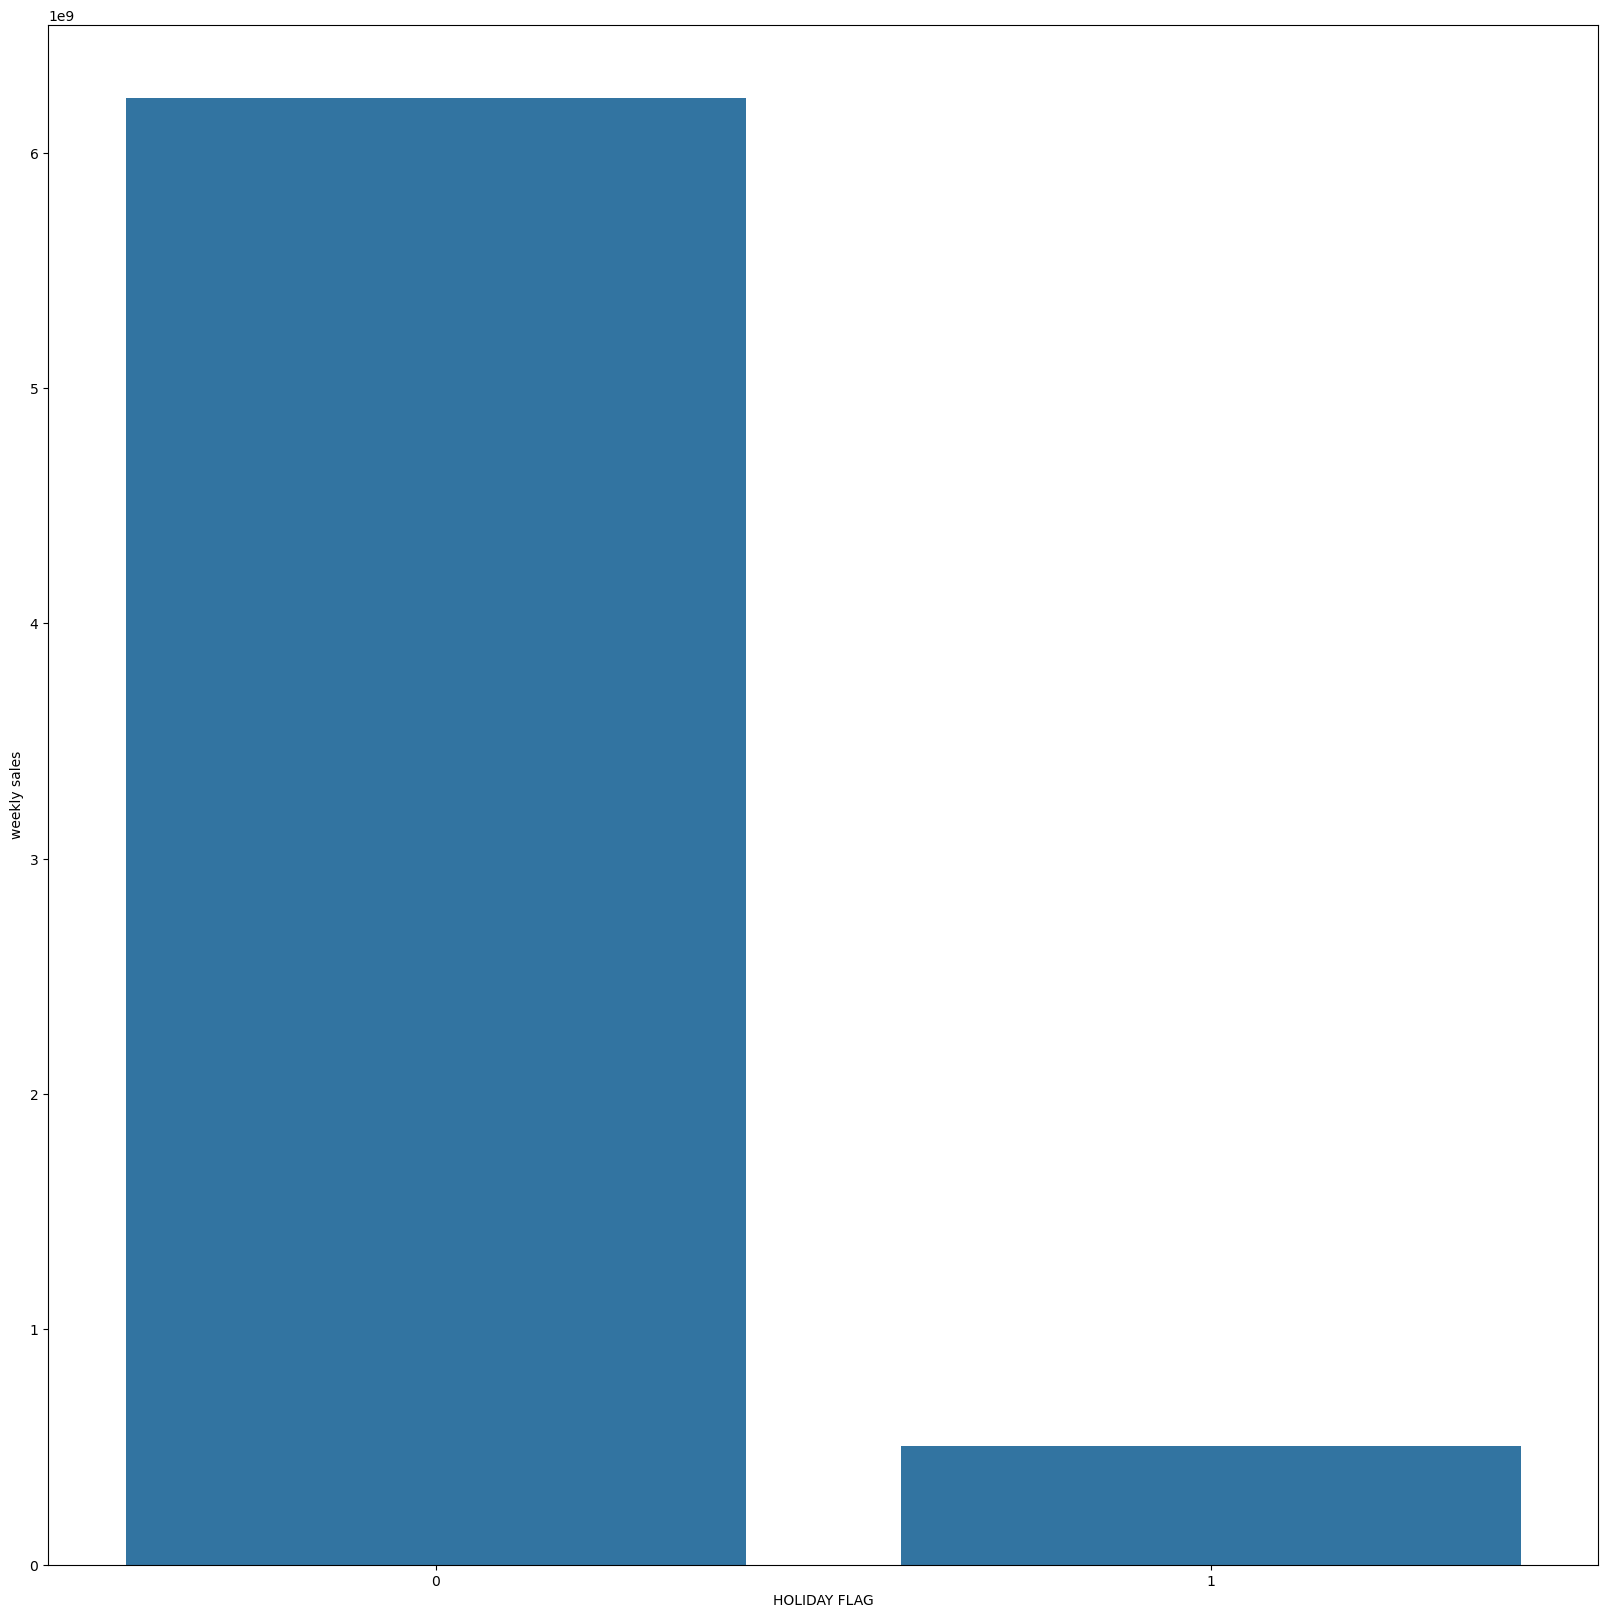

In [42]:
weekly_holiday_sales=df.groupby('Holiday_Flag')['Weekly_Sales'].sum()
pt.figure(figsize=(20,20))
se.barplot(x=weekly_holiday_sales.index,y=weekly_holiday_sales.values)
pt.xlabel('HOLIDAY FLAG')
pt.ylabel('weekly sales')
pt.show()
#conclusion:slaes are on non-holiday is high

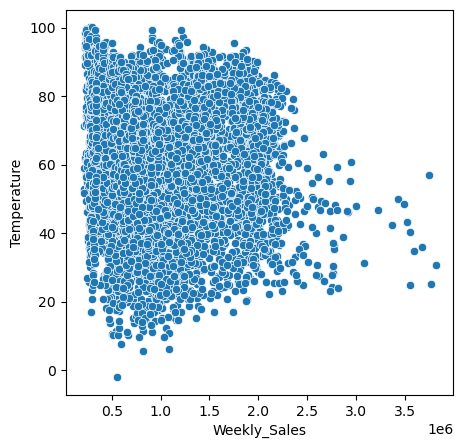

In [9]:
pt.figure(figsize=(5,5))
se.scatterplot(x=df['Weekly_Sales'],y=df['Temperature'])
pt.show()
#conclusion is that the majority of the sales are grouped and some outlayers are present and no co relation

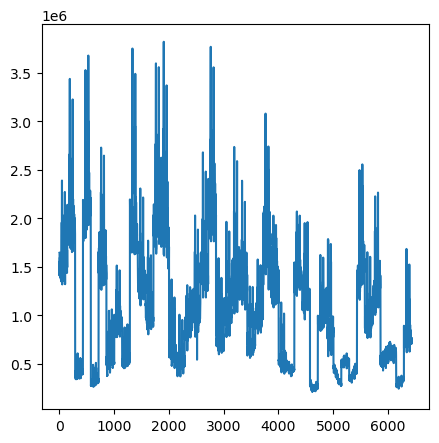

In [33]:
pt.figure(figsize=(5,5))
pt.plot(df['Weekly_Sales'])
pt.show()

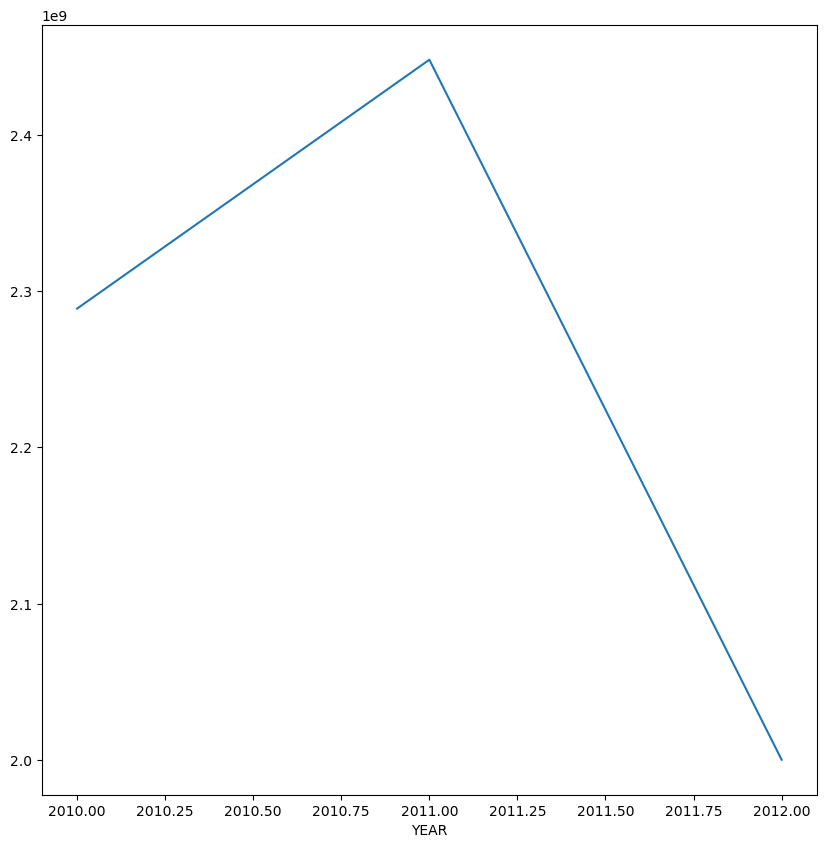

In [31]:
pt.figure(figsize=(10,10))
year_wise_sales=df.groupby('YEAR')['Weekly_Sales'].sum()
year_wise_sales.plot()
pt.show()
#conclusion:there is a spike but also a downfall in slaes overtime

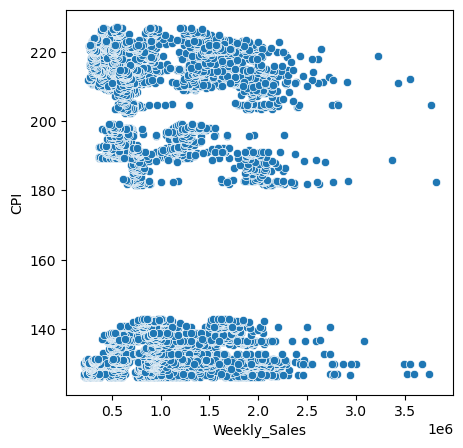

In [36]:
pt.figure(figsize=(5,5))
se.scatterplot(x=df['Weekly_Sales'],y=df['CPI'])
pt.show()
#conclusion:there is no relation b/w sales and consumer price index

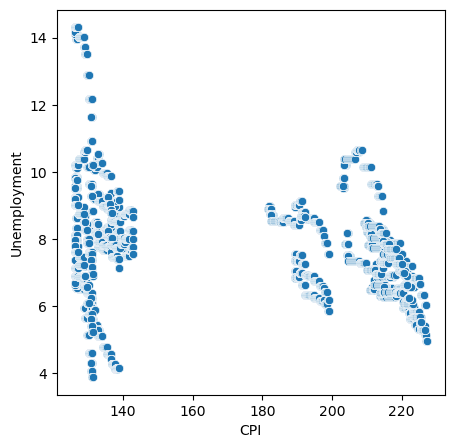

In [49]:
pt.figure(figsize=(5,5))
se.scatterplot(x=df['CPI'],y=df['Unemployment'])
pt.show()

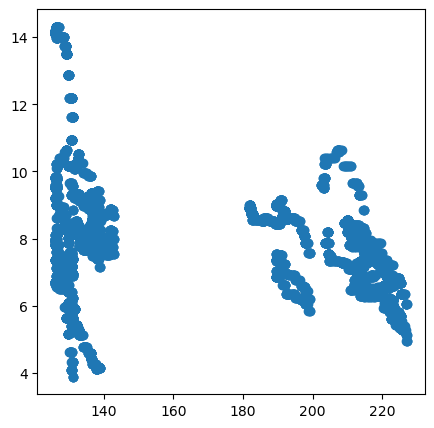

In [5]:
pt.figure(figsize=(5,5))
pt.scatter(df['CPI'],df['Unemployment'])
pt.show()

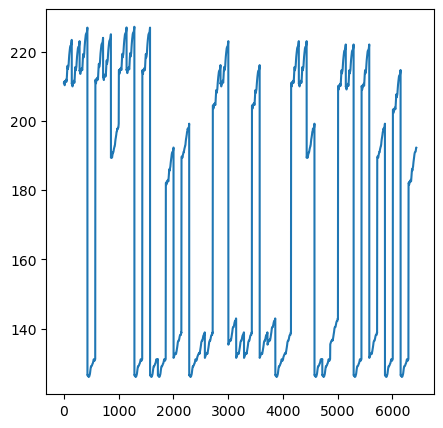

In [47]:
pt.figure(figsize=(5,5))
pt.plot(df['CPI'])
pt.show()

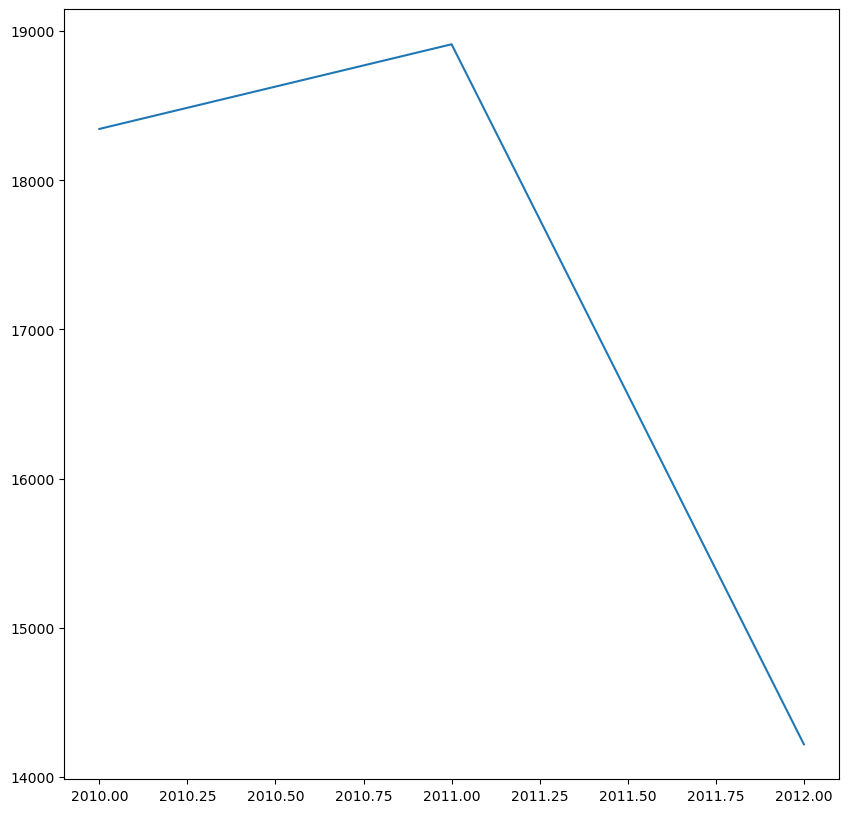

In [75]:
pt.figure(figsize=(10,10))
year=df.groupby('YEAR')['Unemployment'].sum()
pt.plot(year.index,year.values)
pt.show()

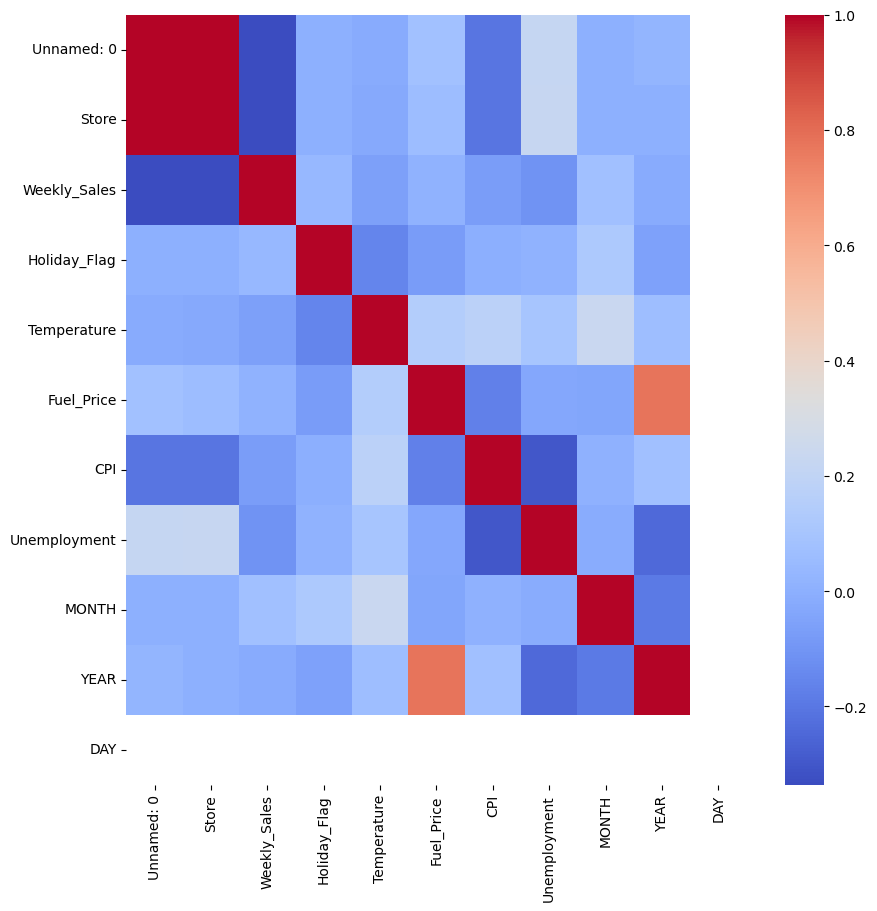

In [69]:
pt.figure(figsize=(10,10))
df_for_corr=df.copy()
df_for_corr.drop(['Date'],axis=1,inplace=True)
corr=df_for_corr.corr()
se.heatmap(corr,cmap='coolwarm')
pt.show()

In [ ]:
#FEATURE ENGINEERING

In [8]:
df['Lag_7']=df['Weekly_Sales'].shift(7)

In [10]:
df['Lag_1']=df['Weekly_Sales'].shift(1)

In [18]:
df['Lag_7']=df['Lag_7'].fillna(0)

In [21]:
df['Lag_1'].fillna(0,inplace=True)

C:\Users\PBS ADITYA\AppData\Local\Temp\ipykernel_12816\3056356777.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Lag_1'].fillna(0,inplace=True)


In [23]:
df['Rolling_mean']=df['Weekly_Sales'].rolling(window=7).mean()

In [25]:
df['Rolling_Meadian']=df['Weekly_Sales'].rolling(window=7).std()

In [45]:
df.drop(columns='cyclic_date',inplace=True)

In [57]:
df.to_csv('working_walmart_data.csv')

In [47]:
df['cyclic_date']=np.sin(2*np.pi*df['DAY']/7)

In [49]:
df['cyclic_month']=np.sin(2*np.pi*df['MONTH']/12)

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6429 entries, 6 to 6434
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       6429 non-null   int64  
 1   Store            6429 non-null   int64  
 2   Date             6429 non-null   object 
 3   Weekly_Sales     6429 non-null   float64
 4   Holiday_Flag     6429 non-null   int64  
 5   Temperature      6429 non-null   float64
 6   Fuel_Price       6429 non-null   float64
 7   CPI              6429 non-null   float64
 8   Unemployment     6429 non-null   float64
 9   MONTH            6429 non-null   int64  
 10  YEAR             6429 non-null   int64  
 11  DAY              6429 non-null   int64  
 12  Lag_7            6429 non-null   float64
 13  Lag_1            6429 non-null   float64
 14  Rolling_mean     6429 non-null   float64
 15  Rolling_Meadian  6429 non-null   float64
 16  cyclic_date      6429 non-null   float64
 17  cyclic_month     64

In [52]:
df = df.dropna()

In [ ]:
#TRAIN TEST SPLIT

In [9]:
from sklearn.model_selection import train_test_split 

In [ ]:
df = df.drop(['Unnamed: 0','Date'], axis=1)
df = df.dropna()

X = df.drop('Weekly_Sales', axis=1)
y = df['Weekly_Sales']

In [74]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=44)

In [65]:
#training model(MACHINE LEARNING)

In [66]:
from xgboost import XGBRegressor

In [67]:
Mymodel = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=44
)

In [76]:
Mymodel.fit(x_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [77]:
y_predicted=Mymodel.predict(x_test)

In [ ]:
#evaluating model

In [14]:
from sklearn.metrics import mean_squared_error

In [81]:
rmse = np.sqrt(mean_squared_error(y_test, y_predicted))
print("RMSE: ", rmse)

RMSE:  94856.35414657343


In [86]:
from sklearn.metrics import r2_score
print("R2 Score:", r2_score(y_test, y_predicted))

R2 Score: 0.9721506012125506


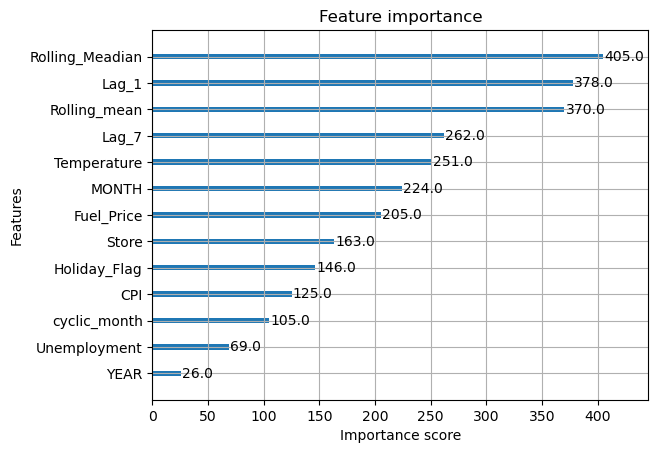

In [84]:
from xgboost import plot_importance
plot_importance(Mymodel)
pt.show()

In [8]:
df = df.drop(['Unnamed: 0','Date'], axis=1)
df = df.dropna()

X1 = df.drop('Weekly_Sales', axis=1)
y1 = df['Weekly_Sales']

In [11]:
x1_train,x1_test,y1_train,y1_test=train_test_split(X1,y1,test_size=0.2,random_state=44)

In [12]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(x1_train, y1_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [13]:
y1_predicted=model.predict(x1_test)

In [16]:
sklearn_results=np.sqrt(mean_squared_error(y1_test,y1_predicted))

In [18]:
print(sklearn_results)

108345.37280813068


In [19]:
from sklearn.metrics import r2_score

In [21]:
sklearn_r2=r2_score(y1_test,y1_predicted)

In [22]:
print(sklearn_r2)

0.9636667954346015


In [ ]:
#conclusion is that XGBRegressor performed well compare to RandomForest